In [1]:
#Install require libaries

In [2]:
!pip install optuna xgboost lightgbm shap -q

In [3]:
#Imports Libaries

In [4]:
import warnings
warnings.filterwarnings('ignore')

import logging
import joblib
import optuna
import shap

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from dataclasses import dataclass

from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.impute import KNNImputer

from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import RobustScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    StackingClassifier
)



from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

Logging records what your program is doing and saves it in a file for monitoring and debugging.

In [5]:
# Logging

logging.basicConfig(
    filename = "training.log",
    level = logging.INFO,
    format = "%(asctime)s - %(levelname)s - %(message)s"
)

logging.info("Project Strated")

This code creates a configuration class that stores all important project settings in one place.

Think of it as a settings file for your ML project.

In [6]:
# Configuration Class
@dataclass

class Config:
  RANDOM_STATE: int = 42
  TEST_SIZE: float = 0.20
  CV_FOLDS: int = 5
  TARGET: str = "Outcome"

cfg = Config()

In [7]:
# Load Dataset

!pip install kagglehub

import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")

# See files inside the folder
print(os.listdir(path))

df = pd.read_csv(f"{path}/diabetes.csv")

df.head()

Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
['diabetes.csv']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
# Data Set Inspection

pd.set_option('display.max_columns', None)

print(df.info())

print(df.describe().T)

print('\n')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
                          count        mean         std     min       25%  \
Pregnancies               768.0    3.845052    3.369578   0.000   1.00000   
Glucose                   768.0  120.894531   31.972618   0.000  99.00000   
Bloo

In [9]:
# Handle Invalid Zero Values
zero_cols = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df[zero_cols] = df[zero_cols].replace(0, np.nan)

In [10]:
# Feature Engineering Transformer

class FeatureEngineer(BaseEstimator, TransformerMixin):

  def fit(self, X, y = None):
    return self

  def transform(self, X):

    X =X.copy()

    X["Glucose_BMI"] = (
            X["Glucose"] *
            X["BMI"]
        )

    X["Age_BMI"] = (
            X["Age"] *
            X["BMI"]
        )

    X["Pregnancy_Age"] = (
            X["Pregnancies"] *
            X["Age"]
        )

    X["Risk_Score"] = (
            0.4 * X["Glucose"] +
            0.3 * X["BMI"] +
            0.3 * X["Age"]
        )

    return X

In [11]:
# Split features
X = df.drop(cfg.TARGET, axis=1)

y = df[cfg.TARGET]

In [12]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = cfg.TEST_SIZE,
    stratify=y,
    random_state= cfg.RANDOM_STATE
)

In [13]:
# Preprocessing Pipeine

numeric_features = X.columns.tolist()

preprocessor = Pipeline(
    steps = [
        ("feature_engineering", FeatureEngineer()),
        ("imputer", KNNImputer(n_neighbors=3)),
        ("scaler", RobustScaler())
    ]
)

In [14]:
# Baseline Logistics Regression

baseline_model = Pipeline(
    [
        ("preprocessing", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=500
            )
        )
    ]
)

baseline_model.fit(
    X_train,
    y_train
)

preds = baseline_model.predict(X_test)

print(
    classification_report(
        y_test,
        preds
    )
)

              precision    recall  f1-score   support

           0       0.74      0.81      0.78       100
           1       0.58      0.48      0.53        54

    accuracy                           0.69       154
   macro avg       0.66      0.65      0.65       154
weighted avg       0.69      0.69      0.69       154



In [15]:
# Optuna Hyperparameter Tuning (XGBoost)

def objective(trial):

    params = {

        "n_estimators":
        trial.suggest_int(
            "n_estimators",
            100,
            500
        ),

        "max_depth":
        trial.suggest_int(
            "max_depth",
            3,
            10
        ),

        "learning_rate":
        trial.suggest_float(
            "learning_rate",
            0.01,
            0.3
        ),

        "subsample":
        trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree":
        trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        )
    }

    model = Pipeline(
        [
            (
                "preprocessing",
                preprocessor
            ),
            (
                "model",
                XGBClassifier(
                    **params,
                    eval_metric="logloss",
                    random_state=42
                )
            )
        ]
    )

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    score = cross_val_score(
        model,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return score

In [16]:
# Run Optimization



study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=30
)

best_params = study.best_params

print(best_params)

[I 2026-06-19 11:50:24,232] A new study created in memory with name: no-name-111a1dc7-1686-47c1-885d-593fd697f2d4
[I 2026-06-19 11:50:27,578] Trial 0 finished with value: 0.8284772978959026 and parameters: {'n_estimators': 484, 'max_depth': 3, 'learning_rate': 0.010505274862425189, 'subsample': 0.7543488442720117, 'colsample_bytree': 0.896189337095207}. Best is trial 0 with value: 0.8284772978959026.
[I 2026-06-19 11:50:28,789] Trial 1 finished with value: 0.7974307862679956 and parameters: {'n_estimators': 269, 'max_depth': 8, 'learning_rate': 0.281214027827334, 'subsample': 0.9636776074543714, 'colsample_bytree': 0.8753990255237253}. Best is trial 0 with value: 0.8284772978959026.
[I 2026-06-19 11:50:31,265] Trial 2 finished with value: 0.806468715393134 and parameters: {'n_estimators': 409, 'max_depth': 10, 'learning_rate': 0.06930115938341955, 'subsample': 0.6331556658854901, 'colsample_bytree': 0.9805875093905346}. Best is trial 0 with value: 0.8284772978959026.
[I 2026-06-19 11:5

{'n_estimators': 117, 'max_depth': 5, 'learning_rate': 0.01141651810298738, 'subsample': 0.7443261127257806, 'colsample_bytree': 0.7437870580870395}


In [17]:
# Train Best Xgboost Model

xgb_pipeline = Pipeline(
    [
        (
            "preprocessing",
            preprocessor
        ),
        (
            "model",
            XGBClassifier(
                **best_params,
                eval_metric="logloss",
                random_state=42
            )
        )
    ]
)

xgb_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('feature_engineering', FeatureEngineer()),
                                 ('imputer', KNNImputer(n_neighbors=3)),
                                 ('scaler', RobustScaler())])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.7437870580870395, device=None,
                               early_stopping_rounds=None,
                               enabl...
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.01141651810298738, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=5,
                               max_leaves=None, min_child_weight=None,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=117,
                               n_jobs=None, num_parallel_tree=None, ...))])

In [18]:
# Evaluation

predictions = xgb_pipeline.predict(
    X_test
)

probabilities = (
    xgb_pipeline
    .predict_proba(X_test)[:,1]
)

accuracy = accuracy_score(
    y_test,
    predictions
)

precision = precision_score(
    y_test,
    predictions
)

recall = recall_score(
    y_test,
    predictions
)

f1 = f1_score(
    y_test,
    predictions
)

roc_auc = roc_auc_score(
    y_test,
    probabilities
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC AUC  :", roc_auc)

Accuracy : 0.7402597402597403
Precision: 0.6666666666666666
Recall   : 0.5185185185185185
F1 Score : 0.5833333333333334
ROC AUC  : 0.8201851851851852


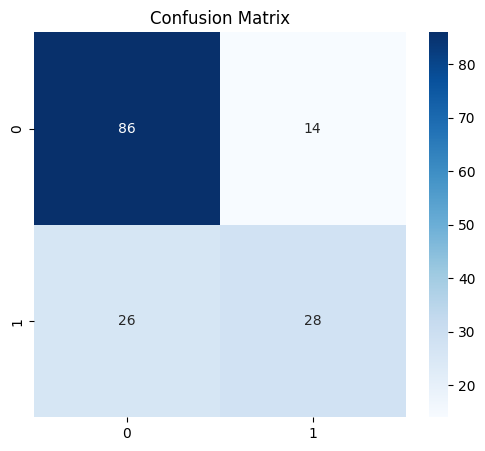

In [19]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.show()

In [20]:
# Cross Validation Score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_score = cross_val_score(
    xgb_pipeline,
    X,
    y,
    scoring="roc_auc",
    cv=cv
)

print(
    "Mean ROC AUC:",
    cv_score.mean()
)

Mean ROC AUC: 0.8361194968553459


In [21]:
# Stacking Ensemble

estimators = [

    (
        "rf",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42
        )
    ),

    (
        "gb",
        GradientBoostingClassifier(
            random_state=42
        )
    ),

    (
        "xgb",
        XGBClassifier(
            eval_metric="logloss",
            random_state=42
        )
    )
]

In [22]:
stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

stack_pipeline = Pipeline(
    [
        (
            "preprocessing",
            preprocessor
        ),
        (
            "stack",
            stack_model
        )
    ]
)

stack_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('feature_engineering', FeatureEngineer()),
                                 ('imputer', KNNImputer(n_neighbors=3)),
                                 ('scaler', RobustScaler())])),
                ('stack',
                 StackingClassifier(estimators=[('rf',
                                                 RandomForestClassifier(n_estimators=300,
                                                                        random_state=42)),
                                                ('gb',
                                                 GradientBoostingClassifier(random_state=42)),
                                                ('xgb',
                                                 XGBClassifier(base_score=None,...
                                                               importance_type=None,
                                                               interaction_constraints=None,
                                                               learning_rate=None,
                                                               max_bin=None,
                                                               max_cat_threshold=None,
                                                               max_cat_to_onehot=None,
                                                               max_delta_step=None,
                                                               max_depth=None,
                                                               max_leaves=None,
                                                               min_child_weight=None,
                                                               missing=nan,
                                                               monotone_constraints=None,
                                                               multi_strategy=None,
                                                               n_estimators=None,
                                                               n_jobs=None,
                                                               num_parallel_tree=None, ...))],
                                    final_estimator=LogisticRegression()))])

In [23]:
# SHAP Explainability

In [24]:
X_processed = preprocessor.fit_transform(
    X_train
)

xgb_model = XGBClassifier(
    **best_params,
    eval_metric="logloss"
)

xgb_model.fit(
    X_processed,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7437870580870395, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01141651810298738,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=117, n_jobs=None,
              num_parallel_tree=None, ...)

In [25]:
explainer = shap.TreeExplainer(
    xgb_model
)

shap_values = explainer.shap_values(
    X_processed
)

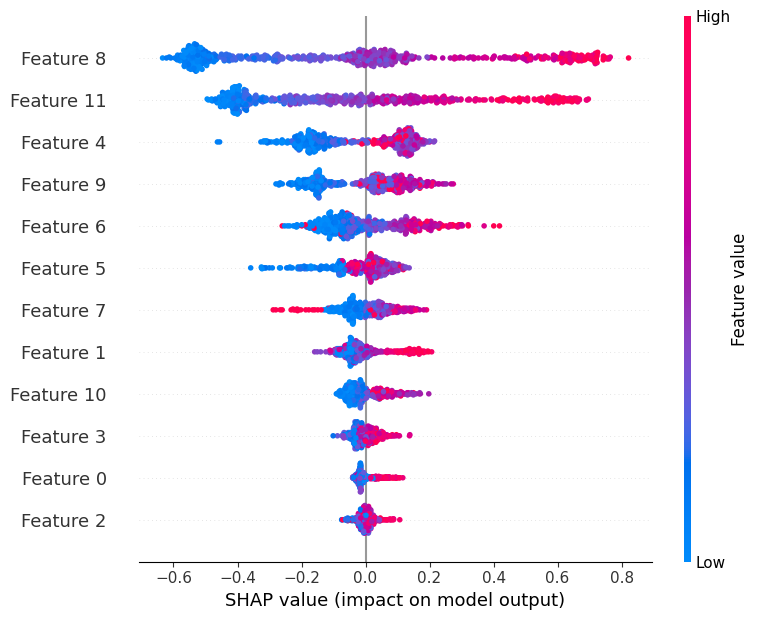

In [26]:
shap.summary_plot(
    shap_values,
    X_processed
)

In [32]:
## Feature importance

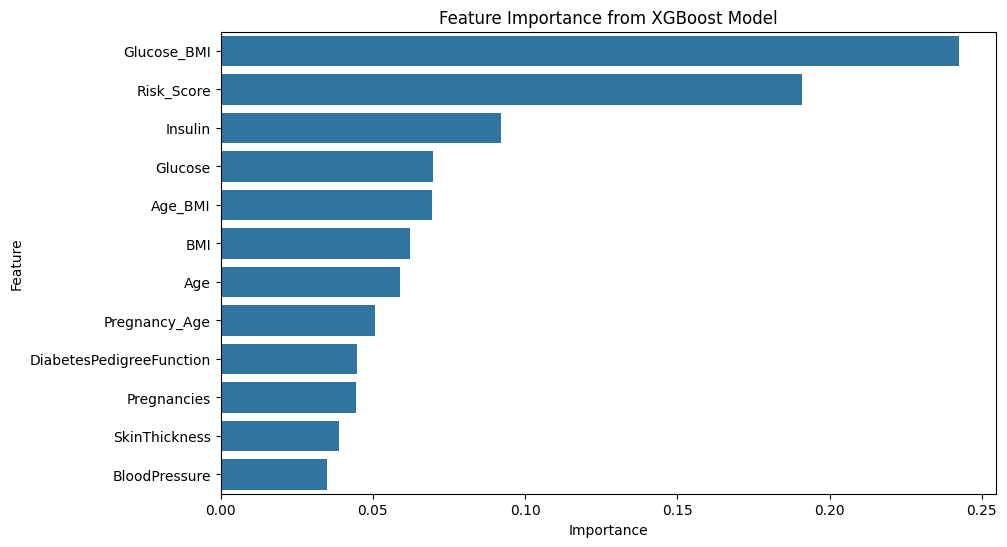

In [31]:
importances = xgb_model.feature_importances_

# Get the feature names after feature engineering
original_features = X.columns.tolist()
engineered_features = [
    "Glucose_BMI",
    "Age_BMI",
    "Pregnancy_Age",
    "Risk_Score"
]

all_features = original_features + engineered_features

importance = pd.DataFrame(
    {
        "Feature": all_features,
        "Importance": importances
    }
)

importance = (
    importance.sort_values(
        "Importance",
        ascending=False
    )
)

plt.figure(
    figsize=(10,6)
)

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance from XGBoost Model")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [33]:
# Error analysis
results = X_test.copy()

results["Actual"] = y_test.values

results["Predicted"] = predictions

errors = results[
    results["Actual"] !=
    results["Predicted"]
]

print(
    f"Errors: {len(errors)}"
)

errors.head()

Errors: 40


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Actual,Predicted
44,7,159.0,64.0,NaN,NaN,27.4,0.294,40,0,1
630,7,114.0,64.0,NaN,NaN,27.4,0.732,34,1,0
387,8,105.0,100.0,36.0,NaN,43.3,0.239,45,1,0
335,0,165.0,76.0,43.0,255.0,47.9,0.259,26,0,1
678,3,121.0,52.0,NaN,NaN,36.0,0.127,25,1,0


In [35]:
# Save Model

joblib.dump(
    xgb_pipeline,
    "diabetes_model.pkl"
)

print(
    "Model Saved Successfully"
)

Model Saved Successfully


In [36]:
# Load Model

model = joblib.load(
    "diabetes_model.pkl"
)

print(
    "Model Loaded Successfully"
)

Model Loaded Successfully


In [37]:
# Predict new Patient

sample = pd.DataFrame(
    {
        "Pregnancies":[2],
        "Glucose":[150],
        "BloodPressure":[80],
        "SkinThickness":[35],
        "Insulin":[130],
        "BMI":[32.5],
        "DiabetesPedigreeFunction":[0.6],
        "Age":[45]
    }
)

prediction = model.predict(sample)

probability = (
    model.predict_proba(sample)
    [:,1]
)

print(
    "Prediction:",
    prediction[0]
)

print(
    "Probability:",
    probability[0]
)

Prediction: 1
Probability: 0.58703417
